# Section: Developing a Ground Truth Radargram

## The basic FDTD gpr simulation

In [1]:
import matplotlib.pyplot as plt
from bruges.filters.wavelets import ricker
import numpy as np

def gpr_finite_difference_abc(
    eps_model,
    dx,
    dz,
    dt,
    t_max,
    f0,
    trace_spacing,
    SNR,
    source_idx
):
    c0 = 3e8
    # Add this check
    lambda_min = (c0 / np.sqrt(np.max(eps_model))) / f0
    points_per_wavelength = lambda_min / dx
    print(f"Points per wavelength: {points_per_wavelength:.1f}")

    nx, nz = eps_model.shape
    velocity = c0 / np.sqrt(eps_model)

    nt = int(t_max / dt)
    t = np.arange(nt) * dt

    # CFL check
    vmax = np.max(velocity)
    if vmax * dt * np.sqrt(1/dx**2 + 1/dz**2) >= 1:
        raise ValueError("CFL unstable — reduce dt.")

    # Source wavelet (generate once)
    w, _ = ricker(duration=1.5 / f0, dt=dt, f=f0)
    w /= np.max(np.abs(w))

    # Shot positions (grid indices)
    positions = np.arange(0, nx, trace_spacing)

    traces = []

    print(positions, nt)
    for x_pos in positions:

        # reset wavefields
        u_prev = np.zeros((nx, nz))
        u = np.zeros((nx, nz))
        u_next = np.zeros((nx, nz))

        trace = np.zeros(nt)

        for it in range(nt):

            # compute Laplacian only on interior
            lap = np.zeros_like(u)
            lap[1:-1,1:-1] = (
                (u[2:,1:-1] - 2*u[1:-1,1:-1] + u[:-2,1:-1]) / dx**2 +
                (u[1:-1,2:] - 2*u[1:-1,1:-1] + u[1:-1,:-2]) / dz**2
            )

            # time update
            u_next = 2*u - u_prev + velocity**2 * dt**2 * lap
            u_next *= 0.999
            # inject source at current position
            if it < len(w):
                u_next[x_pos, source_idx] += w[it]

            # absorbing boundaries
            r_x = velocity * dt / dx
            r_z = velocity * dt / dz

            # left
            u_next[0,:] = (
                u[1,:] +
                (r_x[0,:]-1)/(r_x[0,:]+1) *
                (u_next[1,:] - u[0,:])
            )

            # right
            u_next[-1,:] = (
                u[-2,:] +
                (r_x[-1,:]-1)/(r_x[-1,:]+1) *
                (u_next[-2,:] - u[-1,:])
            )

            # bottom
            u_next[:,-1] = (
                u[:,-2] +
                (r_z[:,-1]-1)/(r_z[:,-1]+1) *
                (u_next[:,-2] - u[:,-1])
            )

            # record monostatic trace
            trace[it] = u_next[x_pos, 1] # top (non-absorbing) bounding?

            u_prev, u = u, u_next.copy()

        # add noise per trace
        if SNR != np.inf:
            noise = np.random.randn(nt)
            noise *= np.std(trace) / np.sqrt(SNR)
            trace += noise

        traces.append(trace)

    radargram = np.array(traces).T  # shape (nt, n_traces)

    return radargram, positions * dx, t


/Users/coltenrodriguez/anaconda3/lib/python3.10/site-packages/bruges/__init__.py:20: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


## A couple misc functions
common implementation of fourier transform using numpy fft and retrieving my custom colormap

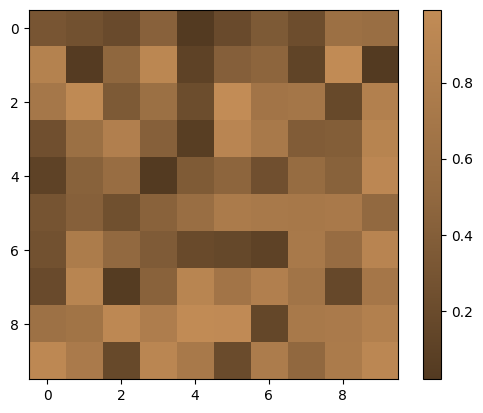

In [10]:
import json
import matplotlib.pyplot as plt
import matplotlib.colors
import numpy as np

def ft(trace, dt):   
    x = np.array(trace)
    n = len(trace)
    X = np.fft.fft(x)
    
    # Frequency axis
    freq = np.fft.fftfreq(n, d=dt)
    
    # Magnitude spectrum
    magnitude = np.abs(X)
    # freq_space_im.append(magnitude)
    
    pos_mask = freq >= 0
    
    return freq[pos_mask], magnitude[pos_mask]

filename = '/Users/coltenrodriguez/Desktop/Senior_Thesis/PreMigration_Processing/custom_cmap.json'

with open(filename, 'r') as f:
    cmap_data_list = json.load(f)

loaded_cmap_rgba = np.array(cmap_data_list)
custom_cmap = matplotlib.colors.ListedColormap(loaded_cmap_rgba, name='recreated_custom_cmap')

# Verify cmap works
data = np.random.rand(10, 10)
plt.imshow(data, cmap=custom_cmap)
plt.colorbar()
plt.show()

## Recreating Relevant Panels in Figures 4 and 5

Uncomment line 8 in the cell bellow to get figure 5 panels B and C

(Text(0.5, 0, 'Distance [m]'),
 Text(0, 0.5, 'Depth [m]'),
 Text(0.5, 1.0, 'Simulation Velocity Model'))

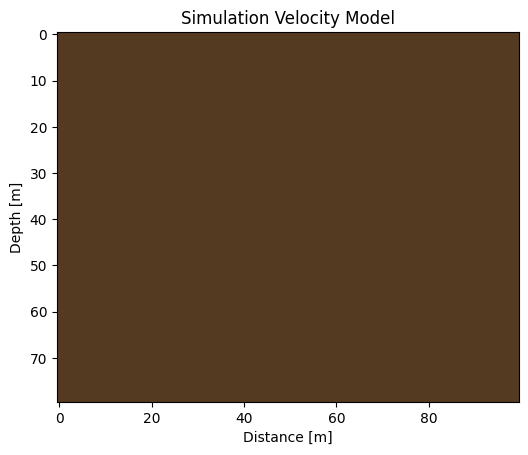

In [11]:
import matplotlib.pyplot as plt
from bruges.filters.wavelets import ricker
import numpy as np
c0=3e8
nx, nz = 80, 100
dx = dz = 1 # 1 m grid
eps = np.ones((nx, nz)) * 4
# eps[8:10, 50:52] = 7  # lower permittivity block

plt.imshow(eps, cmap=custom_cmap)
plt.xlabel('Distance [m]'), plt.ylabel('Depth [m]'), plt.title('Simulation Velocity Model')

In [6]:
dt = 1e-9
t_max = 300e-9
f0 = 2.5e7
np.random.seed(1001)
radargram, x, t = gpr_finite_difference_abc(
    eps.T,
    dx=dx,
    dz=dz,
    dt=dt,
    t_max=t_max,
    f0=f0,
    trace_spacing=1,
    SNR=np.inf,
    source_idx=1
    
)

Points per wavelength: 6.0
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95
 96 97 98 99] 299


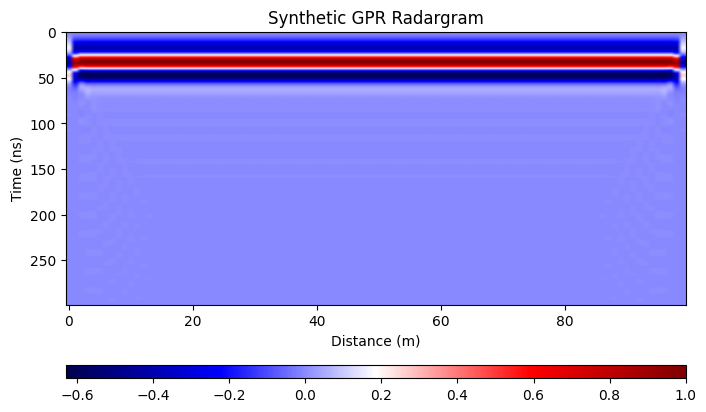

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

data_demeaned = radargram-(np.mean(radargram, axis=1, keepdims=True)*0.3)

fig, ax = plt.subplots(figsize=(8,4.5))
im = ax.imshow(data_demeaned/np.max(data_demeaned), cmap='seismic', aspect='auto')
ax.set_xlabel('Distance (m)')
ax.set_ylabel('Time (ns)')
ax.set_title("Synthetic GPR Radargram")

divider = make_axes_locatable(ax)
cax = divider.new_vertical(size='5%', pad=0.6, pack_start = True)
fig.add_axes(cax)
fig.colorbar(im, cax = cax, orientation = 'horizontal')

plt.show()

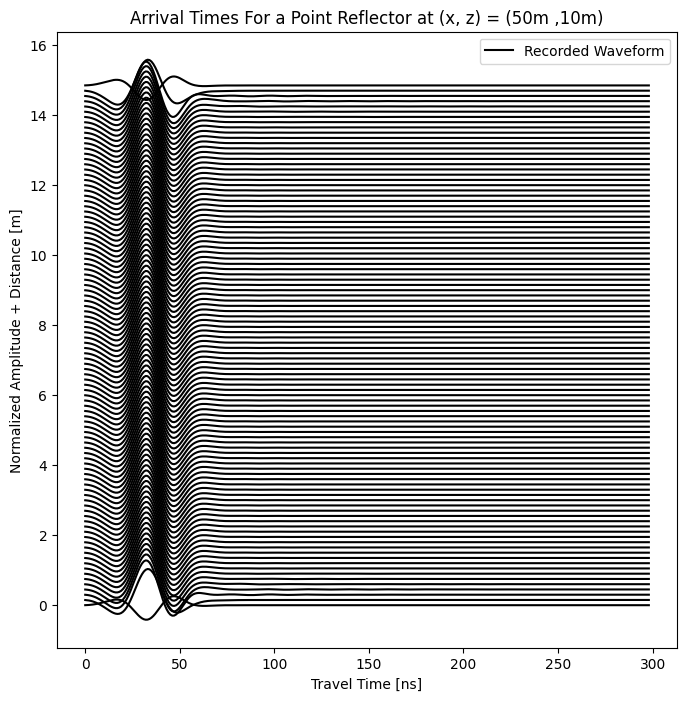

In [8]:
fig = plt.figure(figsize=(8,8))
for i, col in enumerate(data_demeaned.T/data_demeaned.max()):
    if i ==0:
        plt.plot(col+((i)*0.15), '-k', label="Recorded Waveform")
    else:
        plt.plot(col+((i)*0.15), '-k')

plt.title('Arrival Times For a Point Reflector at (x, z) = (50m ,10m)')
plt.xlabel('Travel Time [ns]')
plt.ylabel('Normalized Amplitude + Distance [m]')
plt.legend()

## Check that the centeral frequency matches the parameter f0

In [12]:
mag = []
freq = []
for s in [1, 5, 10, 15, 20]:
    dt = 10e-10
    t_max = 300e-9
    f0 = 2.5e7
    np.random.seed(1001)
    radargram, x, t = gpr_finite_difference_abc(
        eps.T,
        dx=dx,
        dz=dz,
        dt=dt,
        t_max=t_max,
        f0=f0,
        trace_spacing=2,
        SNR=np.inf,
        source_idx = s
    )
    
    stacked_trace = np.mean(radargram, axis=1)
    freqs, mags = ft(stacked_trace, dt=dt)
    mag.append(mags/np.max(mags))
    freq.append(freqs)


Points per wavelength: 6.0
[ 0  2  4  6  8 10 12 14 16 18 20 22 24 26 28 30 32 34 36 38 40 42 44 46
 48 50 52 54 56 58 60 62 64 66 68 70 72 74 76 78 80 82 84 86 88 90 92 94
 96 98] 299
Points per wavelength: 6.0
[ 0  2  4  6  8 10 12 14 16 18 20 22 24 26 28 30 32 34 36 38 40 42 44 46
 48 50 52 54 56 58 60 62 64 66 68 70 72 74 76 78 80 82 84 86 88 90 92 94
 96 98] 299
Points per wavelength: 6.0
[ 0  2  4  6  8 10 12 14 16 18 20 22 24 26 28 30 32 34 36 38 40 42 44 46
 48 50 52 54 56 58 60 62 64 66 68 70 72 74 76 78 80 82 84 86 88 90 92 94
 96 98] 299
Points per wavelength: 6.0
[ 0  2  4  6  8 10 12 14 16 18 20 22 24 26 28 30 32 34 36 38 40 42 44 46
 48 50 52 54 56 58 60 62 64 66 68 70 72 74 76 78 80 82 84 86 88 90 92 94
 96 98] 299
Points per wavelength: 6.0
[ 0  2  4  6  8 10 12 14 16 18 20 22 24 26 28 30 32 34 36 38 40 42 44 46
 48 50 52 54 56 58 60 62 64 66 68 70 72 74 76 78 80 82 84 86 88 90 92 94
 96 98] 299


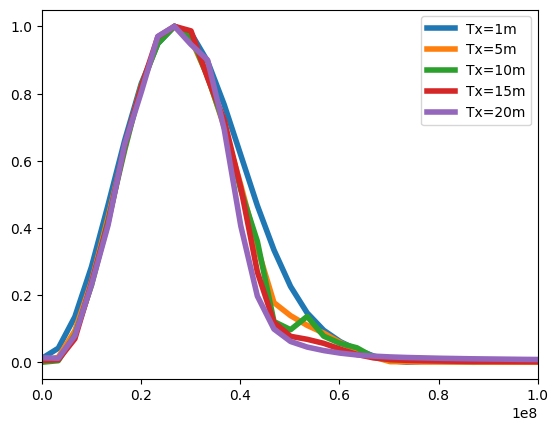

In [13]:
for i in range(len(mag)):
    plt.plot(freq[i], mag[i], markersize=0, linewidth=4, label=f'Tx={[1, 5, 10, 15, 20][i]}m')
plt.xlim(0,1e8)
plt.legend()

## Check that the arrival time is where we expect

We can imagine the exact same process for figure 5, just keeping the source position the same and plotting the expected hyperbolic template

Points per wavelength: 6.0
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95
 96 97 98 99] 299
Points per wavelength: 6.0
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95
 96 97 98 99] 299
Points per wavelength: 6.0
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95
 96 97 

[]

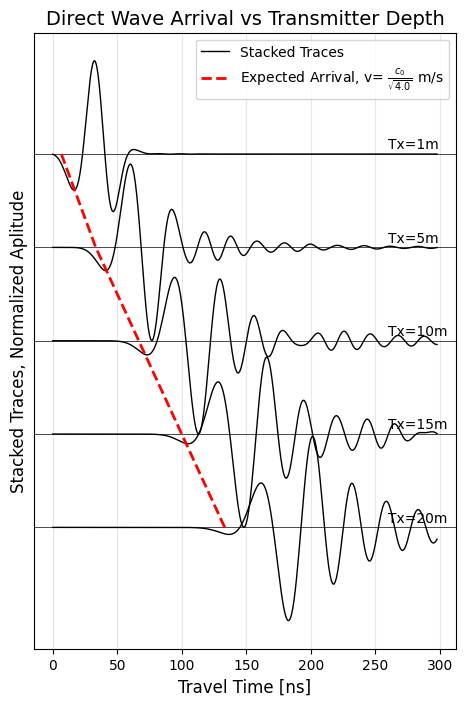

<Figure size 800x400 with 0 Axes>

In [16]:
import matplotlib.pyplot as plt
import numpy as np

fig = plt.figure(figsize=(12, 8))

# Main plot - waterfall style
ax_main = plt.subplot(2, 2, (1, 3))  # spans left side
fig2 = plt.figure(figsize=(8, 4))
offset = 1
# Example data
x = np.linspace(0, 299, 1)
n_traces = 5  # number of stacked plots
sources = [1, 5, 10, 15, 20]
traces_plot= []
grams = []
for i, source in enumerate(sources[::-1]): # run some trials
    
    dt = 1e-9
    t_max = 300e-9
    f0 = 2.5e7
    np.random.seed(1001)
    radargram, x, t = gpr_finite_difference_abc(
        eps.T,
        dx=dx,
        dz=dz,
        dt=dt,
        t_max=t_max,
        f0=f0,
        trace_spacing=1,
        SNR=np.inf,
        source_idx=source
    )
    stack_trace = np.mean(radargram.T, axis=0)
    trace = stack_trace
    trace_norm = trace / np.max(np.abs(trace))
    
    # Plot with offset
    if i == 0:
        ax_main.plot(t * 1e9, trace_norm + i * offset, 'k-', linewidth=1, label="Stacked Traces")
        ax_main.text(260, i * offset+(0.1), f'Tx={source}m', fontsize=10, va='center')
        ax_main.axhline(trace_norm[0] + i * offset, color='black', linewidth=0.5, alpha=1, ms=0)
    else:
        ax_main.plot(t * 1e9, trace_norm + i * offset, 'k-', linewidth=1)
        ax_main.text(260, i * offset+(0.1), f'Tx={source}m', fontsize=10, va='center')
        ax_main.axhline(trace_norm[0] + i * offset, color='black', linewidth=0.5, alpha=1, ms=0)

    grams.append(radargram)
    
# add theoretical prediction
depths = np.array(sources)
epsilon_r = 4.0
velocity = c0 / np.sqrt(epsilon_r)

# Two-way travel time for vertical path
travel_times = depths / velocity * 1e9  # in nanoseconds

ax_main.plot(travel_times[::-1], np.array([0,1,2,3,4])* offset, 'r--', linewidth=2, 
             label=r'Expected Arrival, v= $\frac{c_0}{\sqrt{4.0}}$ m/s')
ax_main.legend()


ax_main.set_xlabel('Travel Time [ns]', fontsize=12)
ax_main.set_ylabel('Stacked Traces, Normalized Aplitude', fontsize=12)
ax_main.set_title('Direct Wave Arrival vs Transmitter Depth', fontsize=14)
ax_main.grid(alpha=0.3)
ax_main.set_yticks([])

## AI disclosure
**only for code in this notebook**
| Cell # | How used |
|---|---|
| 0 |None|
